In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ml_library import KNN, train_test_split, z_score_normalization

In [5]:
df = pd.read_csv("../dataset/train_binary.csv")
df.shape

(50000, 26)

In [6]:
df.sample(5)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,label
37978,636.121053,0.486877,5186.103402,-12.256246,0.005276,54991.912532,602.173806,0.449549,4538.381373,-3.250393,...,118.232937,1.047923,2453.459440,145.111732,0.750851,1158.465207,2.252825,0.137933,-1.0,1
5007,424.939261,0.501762,4115.345205,100.013983,0.005962,40675.842161,396.352945,0.462599,3584.132214,94.855280,...,98.953913,1.052295,3154.209952,87.445895,0.461931,2310.718529,0.884655,-0.896525,-1.0,0
25000,677.843563,0.498271,3971.390675,165.398170,0.004895,49034.204848,644.061438,0.457372,3279.000908,128.021078,...,88.589067,1.039657,2067.752835,169.368765,0.897777,1845.052623,1.663973,0.010113,-1.0,1
6466,667.026786,0.503227,5943.839983,174.128356,0.005448,39062.460662,628.384936,0.462295,5319.548641,135.725548,...,60.573439,0.924983,2354.529101,109.905083,0.265389,2574.112747,1.757509,-0.490177,1.0,0
49030,635.353095,0.500029,4124.044513,181.229375,0.004375,43326.638506,607.616147,0.459890,3708.460416,148.003721,...,88.122827,1.093305,1991.120380,148.297386,0.846072,1202.327009,1.845693,0.416815,1.0,1


In [7]:
X = df.drop("label", axis=1).values
y = df["label"].values

X.shape, y.shape

((50000, 25), (50000,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = z_score_normalization(X_train)
X_test = z_score_normalization(X_test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 25), (10000, 25), (40000,), (10000,))

In [9]:
model = KNN(k=3)

model.fit(X_train, y_train)

In [10]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 0, ..., 0, 0, 1], shape=(10000,))

In [11]:
y_test

array([1, 1, 0, ..., 0, 0, 1], shape=(10000,))

Accuracy: 0.9967
Precision: 0.9973597359735974
Recall: 0.9917952084017067
F1 Score: 0.9945696889912786
Confusion Matrix:
[[6945    8]
 [  25 3022]]


(np.float64(0.9967),
 np.float64(0.9973597359735974),
 np.float64(0.9917952084017067),
 np.float64(0.9945696889912786),
 array([[6945,    8],
        [  25, 3022]]))

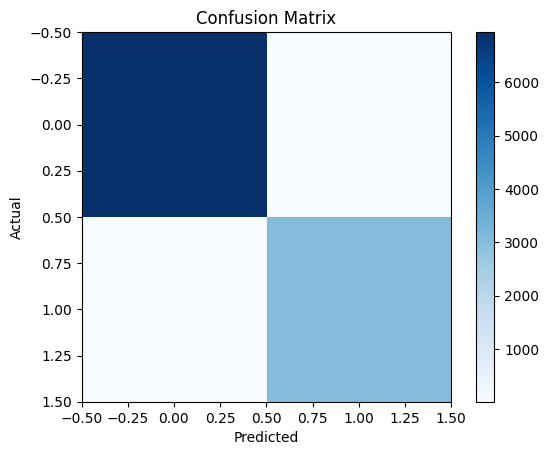

In [12]:
model.evaluation_metrics(y_test, y_pred)

In [14]:
df_testing = pd.read_csv("../dataset/test_binary.csv")

df_testing

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,425.961417,0.499021,5534.216993,158.937483,0.003203,40326.757559,392.911630,0.462618,4839.965545,109.779291,...,8.662481,48.159841,1.055733,2512.532685,81.660268,0.389696,722.416800,1.294156,1.738285,1.0
1,621.169873,0.491361,5451.920192,134.151060,0.004912,46801.608384,586.622737,0.451685,4652.116744,123.802102,...,11.053048,89.110342,1.121912,2878.217512,193.418479,0.367436,1044.469536,0.818993,0.028234,-1.0
2,674.759463,0.497538,4353.708167,144.341660,0.005261,18439.406062,641.720752,0.460264,3963.570118,130.214181,...,13.257430,52.844750,0.976829,2379.556453,208.435965,0.344384,377.734099,1.097345,-0.824431,-1.0
3,555.548489,0.515458,5888.622134,126.766461,0.004454,31774.488278,536.516886,0.474615,5151.605518,94.595414,...,7.519873,115.401214,0.701615,2546.142182,170.688107,0.327638,588.388582,1.037413,0.995409,1.0
4,561.974757,0.494302,5505.669060,109.243006,0.004877,58478.356459,540.144512,0.458056,4862.586548,85.480364,...,7.935664,83.822568,0.801240,2843.177513,239.436877,0.310055,388.434472,0.538400,-0.104211,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,492.723517,0.508662,5913.560355,159.344707,0.005206,54738.158242,472.457007,0.469517,5219.057366,133.117911,...,2.876888,35.088249,0.906149,3300.631174,117.399049,0.378656,788.766705,1.497768,0.097543,-1.0
24996,427.980083,0.499640,3088.382135,92.470930,0.005529,42826.666529,405.896878,0.457697,2745.779108,78.236226,...,8.545169,103.853761,0.960669,2268.050480,113.605043,0.356656,-65.037414,1.917539,-0.379734,1.0
24997,511.624714,0.501069,4948.344231,149.472715,0.007314,44378.616919,473.186438,0.466215,4375.207300,112.984714,...,3.553127,65.697733,0.912177,3161.442108,222.277273,0.308293,1716.849179,0.990802,-1.300893,1.0
24998,644.839477,0.490971,4749.692049,127.073830,0.006809,41178.412309,610.546281,0.450768,4186.151345,102.987013,...,12.076402,55.298350,0.996310,1934.044611,164.819798,0.294823,1227.886470,0.596532,-1.595415,-1.0


In [15]:
X_testing = df_testing.copy().values
X_testing = z_score_normalization(X_testing)
X_testing.shape

(25000, 25)

In [16]:
y_pred_test = model.predict(X_testing)

y_pred_test

array([0, 0, 1, ..., 0, 0, 1], shape=(25000,))

In [18]:
df_testing["target"] = y_pred_test
df_testing.to_csv("../output/knn_binary_class.csv", index=False)